In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import copy

In [2]:
#hvem er nico

df = pd.read_csv("CLeaned_again.csv")
X = df.iloc[:,1:]
y = df["ClaimNb"]
y

0         0
1         0
2         0
3         0
4         0
         ..
541411    0
541412    0
541413    0
541414    0
541415    0
Name: ClaimNb, Length: 541416, dtype: int64

In [110]:
#fan_int = features, fan_out = output
#Kaiming init/HE init
#Used to initialize weights for one hidden layer.
def he_init(fan_in, fan_out):
    std = np.sqrt(2 / fan_in)
    W = np.random.normal(0, std, size=(fan_out, fan_in))
    return W

#Activiation fucntion
def ReLu(arr):
    return np.maximum(0,arr)

#Cost function
def MSE(y_true,y_pred):
    return ((y_true-y_pred)**2).mean()

def forward_pass(X,W,b):
    #Combination
    z= X.dot(W.T)+b
    a = ReLu(z)
    return z,a

matr= he_init(6,4)
np.shape(matr)


(4, 6)

***What this really needs is a way of remembering which weights and biases, and such corresponds to which layer***

**A ToDo, which I will do later/friday or sunday, is add this for the implementation and then try backpropagation**

$\frac{dL}{dZ2}=\frac{2}{m}*(A2-y_{true})$ <- **MSE Gradient**

In [152]:
""" 
Feed-forward
Get p number of features as input layer neurons. Decicde the number of hidden layers and neurons we have in each.
For our we have right now 1 hidden layers with p-2 neurons. For that we will get a linear combination
of weights and inputs for each neuron in the hidden layer. So each input neuron outputs to 4 neurons.

We use the ReLu function to return, a, which is the new values for input. We randomly init weights for that layer using
HE init. With all the a's we compute a linear combination for the output.

Did the math calculations, the logic and with help of LLM to implement it using python.
"""

#1 hidden layer
class neural:
    def __init__(self, input_size, hidden_layers, seed = None):
        if seed is not None:
            np.random.seed(seed) 
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        output_size = 1
        self.weights = {}
        self.bias = {}
        #Creates weight matrix, using HE init. This uses a normal distribution
        #Bias is set to 0 at the start.
        
        for i in range(len(self.hidden_layers)):
            if i == 0:
                in_dim = self.input_size
                out_dim = self.hidden_layers[0]
            else:
                in_dim = self.hidden_layers[i - 1]
                out_dim = self.hidden_layers[i]

            self.weights[f"W{i+1}"] = he_init(in_dim, out_dim).T
            self.bias[f"b{i+1}"] = np.zeros((1, out_dim))

        last_index = len(self.hidden_layers) + 1
        self.weights[f"W{last_index}"] = he_init(self.hidden_layers[-1], output_size).T
        self.bias[f"b{last_index}"] = np.zeros((1,output_size))
        
        #A cache to keep track of the parameters
        self.cache = {}
        self.grad = {}
        
    
 
    def printW(self):
        print("Weight 1: ", self.W1, "Weight 2: ", self.W2)
    #Cost function
    def MSE(self, y_true,y_pred):
        cost = ((y_true-y_pred)**2).mean()
        return cost
    #Activation function
    def ReLu(self, Z):
        return np.maximum(0,Z)
    
    def grad_ReLu(self, Z):
        return (Z>0).astype(float)
    def leakyReLu(self,x ,A=0.2):
        return np.where(x < 0, A * x, x)
    def grad_leakyReLu(self, x, A=0.2):
        return np.where(x < 0, A, 1)
    
    def forward_pass(self, X):
        #First A as X/features
        A = X
        #Save A0 as X, for backpropagation: dWi = A^Ti-1 dot dZi
        self.cache["A0"] = X

        L = len(self.weights)
        for i in range(1,L+1):
            W = self.weights[f"W{i}"]
            b = self.bias[f"b{i}"]
            Z = A.dot(W) + b
            self.cache[f"Z{i}"] = Z

            if i != L:
                A = self.leakyReLu(Z)
            else:
                A = Z
            self.cache[f"A{i}"] = A
        return A

    def backward(self, y_true, learning_rate = 0.001,lambda_reg = 0.001):
        X= self.cache["A0"]
        y_true = y_true.reshape(-1, 1)
        m = y_true.shape[0]

        L = len(self.weights)
        #Should be the output value.
        A_final = self.cache[f"A{L}"]
        #Derivative of MSE
        dA = (2/m)*(A_final-y_true)
        for i in reversed(range(1,L+1)):

            Z = self.cache[f"Z{i}"]
            A_prev = self.cache[f"A{i-1}"]
            W = self.weights[f"W{i}"]
            regularization_term = (lambda_reg / m) * W

            if i == L:
                dZ = dA
            else:
                dZ = dA * self.grad_leakyReLu(Z)

            dW = A_prev.T.dot(dZ)
            db = np.sum(dZ, axis=0, keepdims=True)

            dA = dZ.dot(W.T)

            self.grad[f"dW{i}"] = dW + regularization_term
            self.grad[f"db{i}"] = db
            
        for i in range(1,L+1):
            self.weights[f"W{i}"] -= learning_rate * self.grad[f"dW{i}"]
            self.bias[f"b{i}"] -= learning_rate * self.grad[f"db{i}"]

    def train_batch(self, X, y, mini_batch_size, patience=10, epochs=1000, 
                    learning_rate=0.001, lambda_reg=0.001, validation_split=0.15):
        
        # We now perform the split INSIDE the function!
        # X and y are the combined training + validation data for this fold.
        
        # Convert to numpy arrays and ensure correct shapes
        X_combined = np.array(X)
        y_combined = np.array(y).reshape(-1, 1)
        
        # --- CRITICAL: Internal Split for Early Stopping ---
        if validation_split > 0:
            from sklearn.model_selection import train_test_split
            # Split the combined data into the final training set and the ES validation set
            X, X_val, y, y_val = train_test_split(
                X_combined, y_combined, 
                test_size=validation_split, 
                random_state=42, # Use a fixed seed for reproducibility of the split
                shuffle=True
            )
        else:
            # If no validation split is requested (e.g., for final training on all data)
            X_val, y_val = X_combined, y_combined
            print("Warning: validation_split=0, Early Stopping will use training loss!")
            
        m = X.shape[0]  # Total number of examples in the *new* training set
        L = len(self.weights)

        # Ensure inputs are same length
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"Shape Mismatch after split: X has {X.shape[0]} rows, but y has {y.shape[0]} rows.")

        # --- Early Stopping Variables ---
        best_val_loss = float('inf')
        patience_counter = 0
        best_weights = {k: v.copy() for k, v in self.weights.items()}
        best_bias = {k: v.copy() for k, v in self.bias.items()}
        # --------------------------------

        print(f"Starting training with Early Stopping (Patience: {patience})...")

        for epoch in range(epochs):
            # 1. Training Step
            # Shuffle data at the start of each epoch
            permutation = np.random.permutation(m)
            X_shuffled = X[permutation, :]
            Y_shuffled = y[permutation]

            for start in range(0, m, mini_batch_size):
                end = start + mini_batch_size
                
                X_batch = X_shuffled[start:end, :]
                Y_batch = Y_shuffled[start:end]

                self.forward_pass(X_batch)
                self.backward(Y_batch, learning_rate, lambda_reg)

            # 2. Validation and Early Stopping Check (End of Epoch)
            
            # Predict on the internal validation set
            y_val_pred = self.predict(X_val)
            current_val_loss = self.MSE(y_val, y_val_pred)

            # Predict on the *new* training set (for tracking)
            y_train_pred = self.predict(X) 
            current_train_loss = self.MSE(y, y_train_pred)

            if epoch % 50 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch}/{epochs}, Train Loss: {current_train_loss:.6f}, Val Loss: {current_val_loss:.6f}")

            # Early Stopping Logic
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                patience_counter = 0
                
                # Save the current best model weights
                for k in self.weights:
                    best_weights[k] = self.weights[k].copy()
                for k in self.bias:
                    best_bias[k] = self.bias[k].copy()
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"\n--- Early Stopping Triggered! ---")
                    print(f"Validation loss did not improve for {patience} epochs.")
                    print(f"Best Validation Loss: {best_val_loss:.6f} (Restoring weights)")
                    
                    # Restore best weights before stopping
                    self.weights = best_weights
                    self.bias = best_bias
                    
                    # Return final metrics
                    return current_train_loss, best_val_loss, epoch + 1
                    
        # If the loop completes without stopping, restore the overall best
        print("Completed all epochs. Restoring best weights found during training.")
        self.weights = best_weights
        self.bias = best_bias

        return current_train_loss, best_val_loss, epochs
    def predict(self, X):
        X = np.array(X)
        return self.forward_pass(X)





Batch normalization FFNN

In [57]:
import numpy as np

# Helper function for initialization
def he_init(n_in, n_out):
    return np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)

class batch_NeuralNetwork:
    def __init__(self, input_size, hidden_layers):
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        output_size = 1
        
        # Parameters
        self.weights = {}
        self.bias = {}
        self.gamma = {} # BN Scale
        self.beta = {}  # BN Shift
        
        # BN Running stats (for inference)
        self.running_mean = {}
        self.running_var = {}
        self.momentum = 0.9

        # Initialize Parameters
        for i in range(len(self.hidden_layers)):
            if i == 0:
                in_dim = self.input_size
                out_dim = self.hidden_layers[0]
            else:
                in_dim = self.hidden_layers[i - 1]
                out_dim = self.hidden_layers[i]

            self.weights[f"W{i+1}"] = he_init(in_dim, out_dim)
            self.bias[f"b{i+1}"] = np.zeros((1, out_dim))
            
            # BN Parameters (Initialized to Identity: Gamma=1, Beta=0)
            self.gamma[f"gamma{i+1}"] = np.ones((1, out_dim))
            self.beta[f"beta{i+1}"] = np.zeros((1, out_dim))
            
            # BN Running stats
            self.running_mean[f"rm{i+1}"] = np.zeros((1, out_dim))
            self.running_var[f"rv{i+1}"] = np.zeros((1, out_dim))

        # Output Layer (Usually no BN on output for regression)
        last_index = len(self.hidden_layers) + 1
        self.weights[f"W{last_index}"] = he_init(self.hidden_layers[-1], output_size)
        self.bias[f"b{last_index}"] = np.zeros((1,output_size))
        
        # Storage
        self.cache = {}
        self.grad = {}
        self.grad_bn = {}

    def leakyReLu(self, x, alpha=0.2):
        return np.where(x < 0, alpha * x, x)

    def grad_leakyReLu(self, x, alpha=0.2):
        return np.where(x < 0, alpha, 1)
    
    def forward_pass(self, X, is_training=True):
        A = X
        self.cache["A0"] = X
        L = len(self.weights)
        
        for i in range(1, L + 1):
            W = self.weights[f"W{i}"]
            b = self.bias[f"b{i}"]
            
            # 1. Linear Step
            Z = A.dot(W) + b
            
            # 2. Batch Normalization (Only on Hidden Layers)
            if i != L:
                # Save original Z for backprop steps before overwriting
                self.cache[f"Z_linear{i}"] = Z 

                if is_training:
                    # Calculate mean and var of this batch
                    mu = np.mean(Z, axis=0, keepdims=True)
                    var = np.var(Z, axis=0, keepdims=True)
                    
                    # Normalize
                    Z_norm = (Z - mu) / np.sqrt(var + 1e-8)
                    
                    # Update running stats for inference later
                    self.running_mean[f"rm{i}"] = self.momentum * self.running_mean[f"rm{i}"] + (1 - self.momentum) * mu
                    self.running_var[f"rv{i}"] = self.momentum * self.running_var[f"rv{i}"] + (1 - self.momentum) * var
                    
                    # Save for backward pass
                    self.cache[f"mu{i}"] = mu
                    self.cache[f"var{i}"] = var
                    self.cache[f"Z_norm{i}"] = Z_norm
                else:
                    # Inference Mode: Use running stats
                    mu = self.running_mean[f"rm{i}"]
                    var = self.running_var[f"rv{i}"]
                    Z_norm = (Z - mu) / np.sqrt(var + 1e-8)

                # Scale and Shift
                gamma = self.gamma[f"gamma{i}"]
                beta = self.beta[f"beta{i}"]
                Z_tilde = gamma * Z_norm + beta
                
                # Update Z to be the BN output
                Z = Z_tilde
                
                # Apply Activation
                A = self.leakyReLu(Z)
            
            else:
                # Output layer (Linear, No BN)
                A = Z
            
            # Store Z and A
            self.cache[f"Z{i}"] = Z
            self.cache[f"A{i}"] = A
            
        return A

    def backward(self, y_true, learning_rate=0.001, lambda_reg=0.001):
        m = y_true.shape[0]
        y_true = y_true.reshape(-1, 1)
        L = len(self.weights)
        
        # Initialize Backprop with Output Layer
        A_final = self.cache[f"A{L}"]
        dA = (2/m) * (A_final - y_true) # Gradient of MSE
        
        for i in reversed(range(1, L + 1)):
            A_prev = self.cache[f"A{i-1}"]
            W = self.weights[f"W{i}"]
            
            if i == L:
                # Output Layer (Linear Activation)
                dZ = dA
                dW = A_prev.T.dot(dZ)
                db = np.sum(dZ, axis=0, keepdims=True)
                
                # Regularization for output layer
                dW += (lambda_reg / m) * W
                
                self.grad[f"dW{i}"] = dW
                self.grad[f"db{i}"] = db
                
                # Pass gradient to previous layer
                dA = dZ.dot(W.T)
                
            else:
                # Hidden Layers (BN + LeakyReLU)
                
                # 1. Gradient of Activation
                Z_curr = self.cache[f"Z{i}"] # This is Z_tilde (BN output)
                dZ_tilde = dA * self.grad_leakyReLu(Z_curr)
                
                # 2. Gradient of Batch Norm
                # Retrieve cache
                Z_norm = self.cache[f"Z_norm{i}"]
                var = self.cache[f"var{i}"]
                Z_linear = self.cache[f"Z_linear{i}"] # Z before BN
                mu = self.cache[f"mu{i}"]
                gamma = self.gamma[f"gamma{i}"]
                
                # Gradients for Gamma and Beta
                dgamma = np.sum(dZ_tilde * Z_norm, axis=0, keepdims=True)
                dbeta = np.sum(dZ_tilde, axis=0, keepdims=True)
                
                # Backprop through BN to get dZ_linear
                # (Standard derivation for BN backprop)
                std_inv = 1. / np.sqrt(var + 1e-8)
                dZ_norm = dZ_tilde * gamma
                
                dZ = std_inv * (
                    dZ_norm 
                    - np.mean(dZ_norm, axis=0, keepdims=True) 
                    - Z_norm * np.mean(dZ_norm * Z_norm, axis=0, keepdims=True)
                )

                # 3. Gradients for Weights and Biases
                dW = A_prev.T.dot(dZ)
                db = np.sum(dZ, axis=0, keepdims=True)
                
                # Regularization
                dW += (lambda_reg / m) * W

                # Store gradients
                self.grad[f"dW{i}"] = dW
                self.grad[f"db{i}"] = db
                self.grad_bn[f"dgamma{i}"] = dgamma
                self.grad_bn[f"dbeta{i}"] = dbeta
                
                # Pass gradient to previous layer
                dA = dZ.dot(W.T)

        # Update Parameters
        for i in range(1, L + 1):
            # Update weights/biases
            self.weights[f"W{i}"] -= learning_rate * self.grad[f"dW{i}"]
            self.bias[f"b{i}"] -= learning_rate * self.grad[f"db{i}"]
            
            # Update BN parameters (Only hidden layers)
            if i != L:
                self.gamma[f"gamma{i}"] -= learning_rate * self.grad_bn[f"dgamma{i}"]
                self.beta[f"beta{i}"] -= learning_rate * self.grad_bn[f"dbeta{i}"]

    def train_batch(self,X_train,y_train,X_val=None,y_val=None, mini_batch_size=32,epochs=1000,learning_rate=0.001,
        patience=5,
        min_delta=1e-4
    ):

        X_train = np.array(X_train)
        y_train = np.array(y_train)
        if y_train.ndim == 1:
            y_train = y_train.reshape(-1, 1)

        m = X_train.shape[0]
        L = len(self.weights)

        # Early stopping?
        use_early_stopping = (X_val is not None and y_val is not None)
        if use_early_stopping:
            X_val = np.array(X_val)
            y_val = np.array(y_val).reshape(-1, 1)

            best_val_loss = float('inf')
            patience_counter = 0
            best_model_state = None

        # deterministic shuffling seed
        shuffle_seed = 41

        for epoch in range(epochs):

            # Shuffle
            np.random.seed(shuffle_seed)
            shuffle_seed += 1
            perm = np.random.permutation(m)
            X_shuffled = X_train[perm]
            y_shuffled = y_train[perm]

            # Mini-batches
            for start in range(0, m, mini_batch_size):
                end = start + mini_batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                # Forward + backward
                self.forward_pass(X_batch, is_training=True)
                self.backward(y_batch, learning_rate)

            
            #                   EARLY STOPPING
        
            if use_early_stopping:

                # Full epoch validation forward pass
                val_preds = self.forward_pass(X_val, is_training=False)
                current_val_loss = np.mean((val_preds - y_val) ** 2)

                # Improvement?
                if current_val_loss < best_val_loss - min_delta:
                    best_val_loss = current_val_loss
                    patience_counter = 0

                    # deep copy model parameters
                    best_model_state = {
                        "weights": copy.deepcopy(self.weights),
                        "bias": copy.deepcopy(self.bias),
                        "gamma": copy.deepcopy(self.gamma),
                        "beta": copy.deepcopy(self.beta),
                        "running_mean": copy.deepcopy(self.running_mean),
                        "running_var": copy.deepcopy(self.running_var)
                    }
                else:
                    patience_counter += 1

                # Logging
                if epoch % 50 == 0:
                    print(
                        f"Epoch {epoch} | Val Loss: {current_val_loss:.6f} | "
                        f"Best: {best_val_loss:.6f} | Patience: {patience_counter}/{patience}"
                    )

                # Stop?
                if patience_counter >= patience:
                    print("\nEarly stopping triggered.")
                    print(f"Restoring best model (Val Loss={best_val_loss:.6f})...\n")

                    # Restore
                    self.weights = best_model_state["weights"]
                    self.bias = best_model_state["bias"]
                    self.gamma = best_model_state["gamma"]
                    self.beta = best_model_state["beta"]
                    self.running_mean = best_model_state["running_mean"]
                    self.running_var = best_model_state["running_var"]

                    return {
                        "best_val_loss": best_val_loss,
                        "epochs_run": epoch,
                        "stopped_early": True
                    }

            # =====================================================
            #              TRAINING LOSS LOGGING
            # =====================================================
            if epoch % 50 == 0 and not use_early_stopping:
                # compute full training loss for logging
                full_train_pred = self.forward_pass(X_train, is_training=False)
                train_loss = np.mean((full_train_pred - y_train) ** 2)
                print(f"Epoch {epoch} | Train Loss: {train_loss:.6f}")

        # Finished all epochs normally
        if use_early_stopping:
            return {
                "best_val_loss": best_val_loss,
                "epochs_run": epochs,
                "stopped_early": False
            }
        else:
            return {"epochs_run": epochs, "stopped_early": False}

        





    def predict(self, X):
        # Helper for Inference
        return self.forward_pass(X, is_training=False   )

In [73]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
class NeuralNetworkWrapper(BaseEstimator,RegressorMixin):
    def __init__(self, input_size=7, hidden_layers=None, mini_batch_size=128, epochs=400, learning_rate=0.0001):
        # 1. Initialize all tunable parameters
        # Note: Scikit-learn requires these to be explicitly named here
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.mini_batch_size = mini_batch_size
        self.epochs = epochs
        self.learning_rate = learning_rate
        
        # Placeholders for the actual model
        self.model = None
    def fit(self, X, y):
        # 2. Instantiate your custom model using the parameters
        # We handle mutable defaults (like lists) here, not in __init__
        layers = self.hidden_layers if self.hidden_layers is not None else [100, 80]
        
        self.model = neural(
            input_size=self.input_size, 
            hidden_layers=layers,seed=42
        )
        
        # 3. Call your custom training method
        self.model.train_batch(
            X, 
            y, 
            mini_batch_size=self.mini_batch_size, 
            epochs=self.epochs, 
            learning_rate=self.learning_rate
        )
        self.training_score_ = self.score(X, y)
        
        # fit() must always return self
        return self
    def predict(self, X):
        return self.model.predict(X)
    def score(self, X, y):
        y_pred = self.predict(X)
        MSE = mean_squared_error(y,y_pred)
        return -MSE

In [173]:
df1 = pd.read_csv("data/claims_train.csv")
df1['exposure*bonusmalus'] = df1['Exposure'] * df1['BonusMalus']

df1['Density_over_VehAge'] = df1['Density'] / (df1['VehAge'] + 1e-6)
X = df1[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge']]
X = pd.get_dummies(X, drop_first=True, dtype="int")
y = df1['ClaimNb']
X

y_binned = pd.cut(y,bins=5,labels=False,include_lowest=True)

In [174]:
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y_binned)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
y_train_scaled = np.log(y_train+1)
np.mean(y_train)

np.float64(0.052862905505559145)

Best Parameters: {'epochs': 400, 'hidden_layers': [100, 50, 20], 'learning_rate': 0.01, 'mini_batch_size': 64}
Best Score: 0.022957925930353878

In [151]:
new_n = batch_NeuralNetwork(input_size=9, hidden_layers=[100, 50, 20])
#Batch-norm
new_n.train_batch(X_train_scaled,y_train_scaled, mini_batch_size=32,epochs=25, learning_rate=0.01)

ValueError: shapes (32,9) and (100,9) not aligned: 9 (dim 1) != 100 (dim 0)

In [180]:
new_n2 = neural(input_size=9, hidden_layers=[100,50,20],seed=42)
#No batch-norm
new_n2.train_batch(X_train_scaled,y_train, mini_batch_size=42,epochs=175, learning_rate=0.009)

Starting training with Early Stopping (Patience: 10)...
Epoch 0/175, Train Loss: 0.056641, Val Loss: 0.057008
Epoch 50/175, Train Loss: 0.055517, Val Loss: 0.055918

--- Early Stopping Triggered! ---
Validation loss did not improve for 10 epochs.
Best Validation Loss: 0.055803 (Restoring weights)


(np.float64(0.05544110721735135), np.float64(0.055803359078092904), 68)

Best Parameters: {'epochs': 175, 'hidden_layers': [100, 50, 20], 'learning_rate': 0.009, 'mini_batch_size': 42}
Best Score: 0.02364311025484696

In [181]:
y_test = np.array(y_test)
if y_test.ndim == 1:
    y_test = y_test.reshape(-1, 1)
y_test

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(135603, 1))

In [182]:
#y_pred_BN = new_n.predict(X_test_scaled)
y_pred_normal = new_n2.predict(X_test_scaled)
y_pred_unscaled = np.exp(y_pred_normal) - 1
#mse = np.mean((y_pred_BN - y_test)**2)

In [63]:
y_mean = np.mean(y_test)

# Sum of Squares Residual (SSR) - Error from your model
SS_residual = np.sum((y_test - y_pred_BN)**2)

# Sum of Squares Total (SST) - Error from the baseline mean
SS_total = np.sum((y_test - y_mean)**2)

# R-squared calculation
r2 = 1 - (SS_residual / SS_total)
r2

np.float64(0.019006407240824363)

In [183]:
y_mean = np.mean(y_test)

# Sum of Squares Residual (SSR) - Error from your model
SS_residual = np.sum((y_test - y_pred_normal)**2)

# Sum of Squares Total (SST) - Error from the baseline mean
SS_total = np.sum((y_test - y_mean)**2)

# R-squared calculation
r2 = 1 - (SS_residual / SS_total)
r2

np.float64(0.023965108904545285)

***Cross validation & Grid Search***

In [ ]:
new_n = batch_NeuralNetwork(input_size=9, hidden_layers=[100, 50, 20])
new_n.train_batch(X_train_scaled,y_train, mini_batch_size=32,epochs=400, learning_rate=0.01)

In [52]:
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [75]:
num_folds = 5
learning_rates = [0.01,0.005,0.001]
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
results = {}

for lr in learning_rates:
    print(f"Testing learning rate: {lr}")

    model = NeuralNetworkWrapper(
        input_size=9, # Assuming this is the correct input size
        hidden_layers=[100, 50, 20],
        mini_batch_size=32,
        epochs=25,
        learning_rate=lr # The hyperparameter being tested
    )
    #model.fit(X_train_scaled,y_train)
    cv_scores = cross_val_score(model,X_scaled,y,cv=kf)
    results[lr] = {
        'scores': cv_scores,
        'mean_score': cv_scores.mean(),
        'std_dev': cv_scores.std()
    }
    print(f"  Mean Score: {results[lr]['mean_score']:.4f}, Std Dev: {results[lr]['std_dev']:.4f}\n")

Testing learning rate: 0.01
Epoch 0, Batch Loss: 0.003188
Epoch 0, Batch Loss: 0.001099
Epoch 0, Batch Loss: 0.001278
Epoch 0, Batch Loss: 0.003326
Epoch 0, Batch Loss: 0.005900
  Mean Score: -0.0558, Std Dev: 0.0013

Testing learning rate: 0.005
Epoch 0, Batch Loss: 0.004610
Epoch 0, Batch Loss: 0.002136
Epoch 0, Batch Loss: 0.002599
Epoch 0, Batch Loss: 0.004455
Epoch 0, Batch Loss: 0.007489
  Mean Score: -0.0559, Std Dev: 0.0013

Testing learning rate: 0.001
Epoch 0, Batch Loss: 0.012370
Epoch 0, Batch Loss: 0.007062
Epoch 0, Batch Loss: 0.002765
Epoch 0, Batch Loss: 0.013858
Epoch 0, Batch Loss: 0.018540
  Mean Score: -0.0560, Std Dev: 0.0013



**Batch normalization loss, CV, learning rates.**

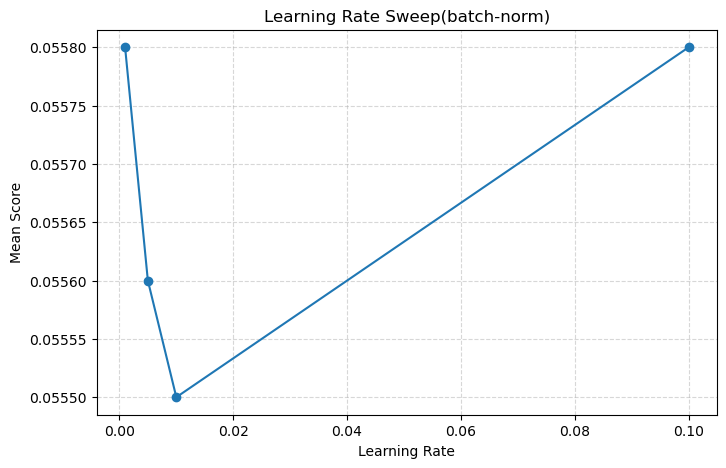

In [86]:
lrs = np.array([0.1, 0.01,0.005, 0.001])
#Batch norm scores for the different learning rates.
mean_scores = np.array([-0.0558, -0.0555, -0.0556, -0.0558])
std_scores = np.array([0.0013, 0.0010, 0.0011, 0.0012])

plt.figure(figsize=(8,5))

# Plot with error bars
#plt.errorbar(lrs, mean_scores, yerr=std_scores, fmt='o-', capsize=5)
plt.plot(lrs,-mean_scores, marker="o")

# Log scale for LR (important!)
#plt.xscale('log')

plt.xlabel("Learning Rate")
plt.ylabel("Mean Score")
plt.title("Learning Rate Sweep(batch-norm)")

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

**FFNN loss in CV, for learning rates. Didnt include 0.10 because it exploded**

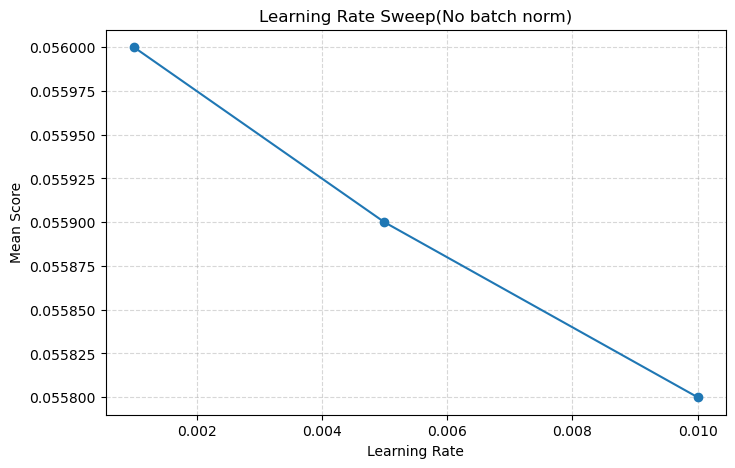

In [85]:
lrs_ffnn = [0.01,0.005,0.001]
mean_scores_ffnn = [0.0558,0.0559,0.0560]
plt.figure(figsize=(8,5))

# Plot with error bars
#plt.errorbar(lrs, mean_scores, yerr=std_scores, fmt='o-', capsize=5)
plt.plot(lrs_ffnn,mean_scores_ffnn, marker="o")

# Log scale for LR (important!)
#plt.xscale('log')

plt.xlabel("Learning Rate")
plt.ylabel("Mean Score")
plt.title("Learning Rate Sweep(No batch norm)")

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [76]:
results

{0.01: {'scores': array([-0.05643793, -0.05363086, -0.05734212, -0.05495388, -0.05647924]),
  'mean_score': np.float64(-0.055768803776885624),
  'std_dev': np.float64(0.001316259569717337)},
 0.005: {'scores': array([-0.05650025, -0.0537036 , -0.0575024 , -0.05507508, -0.05657555]),
  'mean_score': np.float64(-0.05587137688875323),
  'std_dev': np.float64(0.0013330350568531474)},
 0.001: {'scores': array([-0.05667538, -0.05386775, -0.05760833, -0.05524179, -0.05675453]),
  'mean_score': np.float64(-0.0560295553764202),
  'std_dev': np.float64(0.0013212988682761067)}}

In [58]:
num_folds = 5
epochs = [10,25,50,100,200,400]
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
result_epoch = {}

for epoch in epochs:
    print(f"Testing epoch: {epoch}")

    model = NeuralNetworkWrapper(
        input_size=9, # Assuming this is the correct input size
        hidden_layers=[100, 50, 20],
        mini_batch_size=32,
        epochs=epoch,
        learning_rate=0.01 # The hyperparameter being tested
    )
    model.fit(X_train_scaled,y_train)
    cv_scores = cross_val_score(model,X_scaled,y,cv=kf)
    result_epoch[epoch] = {
        'scores': cv_scores,
        'mean_score': cv_scores.mean(),
        'std_dev': cv_scores.std()
    }
    print(f"  Mean Score: {result_epoch[epoch]['mean_score']:.4f}, Std Dev: {result_epoch[epoch]['std_dev']:.4f}\n")

Testing epoch: 10
Epoch 0 | Train Loss: 0.056174
Epoch 0 | Train Loss: 0.056168
Epoch 0 | Train Loss: 0.056949
Epoch 0 | Train Loss: 0.055955
Epoch 0 | Train Loss: 0.056669
Epoch 0 | Train Loss: 0.056031
  Mean Score: -0.0563, Std Dev: 0.0014

Testing epoch: 25
Epoch 0 | Train Loss: 0.056146
Epoch 0 | Train Loss: 0.056258
Epoch 0 | Train Loss: 0.056893
Epoch 0 | Train Loss: 0.055881
Epoch 0 | Train Loss: 0.056552
Epoch 0 | Train Loss: 0.055997
  Mean Score: -0.0562, Std Dev: 0.0013

Testing epoch: 50
Epoch 0 | Train Loss: 0.056016
Epoch 0 | Train Loss: 0.056224
Epoch 0 | Train Loss: 0.056887
Epoch 0 | Train Loss: 0.055835
Epoch 0 | Train Loss: 0.056594
Epoch 0 | Train Loss: 0.056038
  Mean Score: -0.0559, Std Dev: 0.0013

Testing epoch: 100
Epoch 0 | Train Loss: 0.056154
Epoch 50 | Train Loss: 0.055679
Epoch 0 | Train Loss: 0.056063
Epoch 50 | Train Loss: 0.055656
Epoch 0 | Train Loss: 0.057151
Epoch 50 | Train Loss: 0.056266
Epoch 0 | Train Loss: 0.055913
Epoch 50 | Train Loss: 0.0553

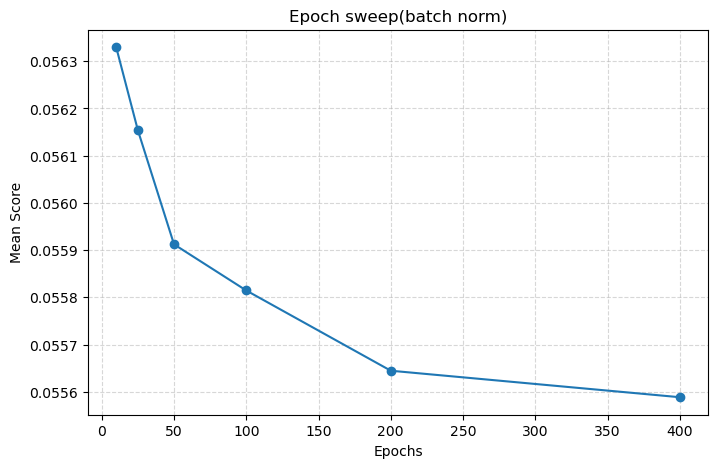

In [93]:
epochs = [10,25,50,100,200,400]
all_mean_scores_epoch = [result_epoch[e]['mean_score'] for e in result_epoch]
real_mse_scores = [-v['mean_score'] for v in result_epoch.values()]
plt.figure(figsize=(8,5))

# Plot with error bars
#plt.errorbar(lrs, mean_scores, yerr=std_scores, fmt='o-', capsize=5)
plt.plot(epochs,real_mse_scores, marker="o")

# Log scale for LR (important!)
#plt.xscale('log')

plt.xlabel("Epochs")
plt.ylabel("Mean Score")
plt.title("Epoch sweep(batch norm)")

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [94]:
num_folds = 5
epochs = [10,25,50,100,200,400]
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
result_epoch_ffnn = {}

for epoch in epochs:
    print(f"Testing epoch: {epoch}")

    model = NeuralNetworkWrapper(
        input_size=9, # Assuming this is the correct input size
        hidden_layers=[100, 50, 20],
        mini_batch_size=32,
        epochs=epoch,
        learning_rate=0.01 # The hyperparameter being tested
    )
    model.fit(X_train_scaled,y_train)
    cv_scores = cross_val_score(model,X_scaled,y,cv=kf)
    result_epoch_ffnn[epoch] = {
        'scores': cv_scores,
        'mean_score': cv_scores.mean(),
        'std_dev': cv_scores.std()
    }
    print(f"  Mean Score: {result_epoch[epoch]['mean_score']:.4f}, Std Dev: {result_epoch[epoch]['std_dev']:.4f}\n")

Testing epoch: 10
Epoch 0, Batch Loss: 0.306642
Epoch 0, Batch Loss: 0.003188
Epoch 0, Batch Loss: 0.001099
Epoch 0, Batch Loss: 0.001278
Epoch 0, Batch Loss: 0.003326
Epoch 0, Batch Loss: 0.005900
  Mean Score: -0.0563, Std Dev: 0.0014

Testing epoch: 25
Epoch 0, Batch Loss: 0.306642
Epoch 0, Batch Loss: 0.003188
Epoch 0, Batch Loss: 0.001099
Epoch 0, Batch Loss: 0.001278
Epoch 0, Batch Loss: 0.003326
Epoch 0, Batch Loss: 0.005900
  Mean Score: -0.0562, Std Dev: 0.0013

Testing epoch: 50
Epoch 0, Batch Loss: 0.306642
Epoch 0, Batch Loss: 0.003188
Epoch 0, Batch Loss: 0.001099
Epoch 0, Batch Loss: 0.001278
Epoch 0, Batch Loss: 0.003326
Epoch 0, Batch Loss: 0.005900
  Mean Score: -0.0559, Std Dev: 0.0013

Testing epoch: 100
Epoch 0, Batch Loss: 0.306642
Epoch 0, Batch Loss: 0.003188
Epoch 0, Batch Loss: 0.001099
Epoch 0, Batch Loss: 0.001278
Epoch 0, Batch Loss: 0.003326
Epoch 0, Batch Loss: 0.005900
  Mean Score: -0.0558, Std Dev: 0.0013

Testing epoch: 200
Epoch 0, Batch Loss: 0.30664

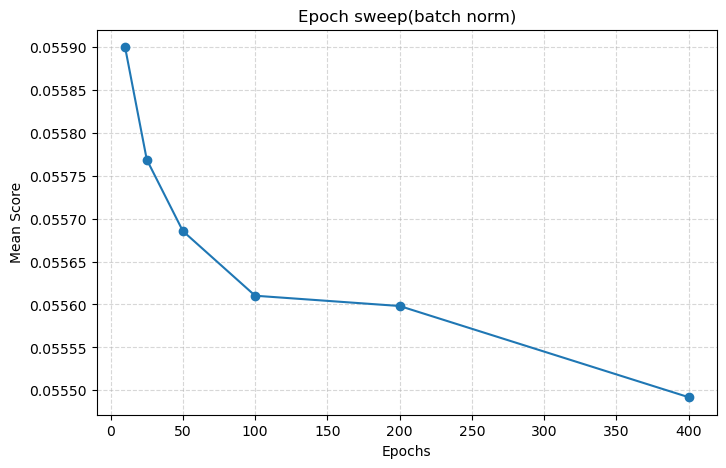

In [95]:
epochs = [10,25,50,100,200,400]
all_mean_scores_epoch = [result_epoch_ffnn[e]['mean_score'] for e in result_epoch_ffnn]
real_mse_scores = [-v['mean_score'] for v in result_epoch_ffnn.values()]
plt.figure(figsize=(8,5))

# Plot with error bars
#plt.errorbar(lrs, mean_scores, yerr=std_scores, fmt='o-', capsize=5)
plt.plot(epochs,real_mse_scores, marker="o")

# Log scale for LR (important!)
#plt.xscale('log')

plt.xlabel("Epochs")
plt.ylabel("Mean Score")
plt.title("Epoch sweep(batch norm)")

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [97]:
num_folds = 5
mini_batch = [32,64,128,256]
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
mb_ffnn = {}

for mb in mini_batch:
    print(f"Testing mb: {mb}")

    model = NeuralNetworkWrapper(
        input_size=9, # Assuming this is the correct input size
        hidden_layers=[100, 50, 20],
        mini_batch_size=mb,
        epochs=400,
        learning_rate=0.01 # The hyperparameter being tested
    )
    model.fit(X_train_scaled,y_train)
    cv_scores = cross_val_score(model,X_scaled,y,cv=kf)
    mb_ffnn[mb] = {
        'scores': cv_scores,
        'mean_score': cv_scores.mean(),
        'std_dev': cv_scores.std()
    }
    print(f"  Mean Score: {mb_ffnn[mb]['mean_score']:.4f}, Std Dev: {mb_ffnn[mb]['std_dev']:.4f}\n")

Testing mb: 32
Epoch 0, Batch Loss: 0.306642
Epoch 100, Batch Loss: 0.002708
Epoch 200, Batch Loss: 0.042102
Epoch 300, Batch Loss: 0.074954
Epoch 0, Batch Loss: 0.003188
Epoch 100, Batch Loss: 0.008688
Epoch 200, Batch Loss: 0.096242
Epoch 300, Batch Loss: 0.005572
Epoch 0, Batch Loss: 0.001099
Epoch 100, Batch Loss: 0.117690
Epoch 200, Batch Loss: 0.007785
Epoch 300, Batch Loss: 0.576374
Epoch 0, Batch Loss: 0.001278
Epoch 100, Batch Loss: 0.008965
Epoch 200, Batch Loss: 0.108629
Epoch 300, Batch Loss: 0.116391
Epoch 0, Batch Loss: 0.003326
Epoch 100, Batch Loss: 0.001523
Epoch 200, Batch Loss: 0.006464
Epoch 300, Batch Loss: 0.009954
Epoch 0, Batch Loss: 0.005900
Epoch 100, Batch Loss: 0.003176
Epoch 200, Batch Loss: 0.005998
Epoch 300, Batch Loss: 0.126217
  Mean Score: -0.0555, Std Dev: 0.0013

Testing mb: 64
Epoch 0, Batch Loss: 0.286461
Epoch 100, Batch Loss: 0.002405
Epoch 200, Batch Loss: 0.043195
Epoch 300, Batch Loss: 0.077524
Epoch 0, Batch Loss: 0.004372
Epoch 100, Batch L

Best LR:0.001; best epoch:400, but we use 200; best mb:32.

For every CV we used an arbitary number of hidden layers and neurons. This might be differnet now doing gridsearch.

In [102]:
param_grid = {
    'hidden_layers': [
        [200, 100, 50], 
        [100,50], 
        [100, 50, 20],
        [80,60,40,20]
    ],
    'learning_rate': [0.001,0.003,0.005,0.009],
    'mini_batch_size': [32, 42,52,62],
    'epochs': [175,200,225,250,275,300]
}

In [120]:
nn_wrapper = NeuralNetworkWrapper(input_size=9)

# 2. Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=nn_wrapper,
    param_grid=param_grid,
    scoring='r2', # Or 'r2' for regression
    cv=3,                             # Number of cross-validation folds
    n_jobs=5,                        # Use all CPU cores
    verbose=2,
    return_train_score=True
)

# 3. Run the search
# Note: X_train_scaled and y_train must be numpy arrays
print("Starting Grid Search...")
grid_search.fit(X_scaled, y)

# 4. Get results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

# You can now use the best model directly
best_model = grid_search.best_estimator_
#predictions = best_model.predict()


Starting Grid Search...
Fitting 3 folds for each of 384 candidates, totalling 1152 fits
Starting training with Early Stopping (Patience: 10)...
Starting training with Early Stopping (Patience: 10)...
Starting training with Early Stopping (Patience: 10)...
Starting training with Early Stopping (Patience: 10)...
Starting training with Early Stopping (Patience: 10)...
Epoch 0/175, Train Loss: 0.062461, Val Loss: 0.062666
Epoch 0/175, Train Loss: 0.063231, Val Loss: 0.061201
Epoch 0/175, Train Loss: 0.061376, Val Loss: 0.061602
Epoch 0/175, Train Loss: 0.062145, Val Loss: 0.060068
Epoch 0/175, Train Loss: 0.061462, Val Loss: 0.059651
Epoch 50/175, Train Loss: 0.055607, Val Loss: 0.056039
Epoch 50/175, Train Loss: 0.056255, Val Loss: 0.054330
Epoch 50/175, Train Loss: 0.056186, Val Loss: 0.054276
Epoch 50/175, Train Loss: 0.055669, Val Loss: 0.053945
Epoch 50/175, Train Loss: 0.055552, Val Loss: 0.055993

--- Early Stopping Triggered! ---
Validation loss did not improve for 10 epochs.
Best 

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Starting training with Early Stopping (Patience: 10)...
Epoch 0/175, Train Loss: 0.058556, Val Loss: 0.058914
Epoch 100/175, Train Loss: 0.055528, Val Loss: 0.055950

--- Early Stopping Triggered! ---
Validation loss did not improve for 10 epochs.
Best Validation Loss: 0.055762 (Restoring weights)
Epoch 100/175, Train Loss: 0.055689, Val Loss: 0.053983
[CV] END epochs=175, hidden_layers=[200, 100, 50], learning_rate=0.003, mini_batch_size=32; total time= 6.2min
Starting training with Early Stopping (Patience: 10)...
Epoch 0/175, Train Loss: 0.058948, Val Loss: 0.057215

--- Early Stopping Triggered! ---
Validation loss did not improve for 10 epochs.
Best Validation Loss: 0.053867 (Restoring weights)
[CV] END epochs=175, hidden_layers=[200, 100, 50], learning_rate=0.001, mini_batch_size=62; total time= 8.4min
Starting training with Early Stopping (Patience: 10)...
Epoch 0/175, Train Loss: 0.061271, Val Loss: 0.059246

--- Early Stopping Triggered! ---
Validation loss did not improve for

Best Parameters: {'epochs': 400, 'hidden_layers': [100, 50, 20], 'learning_rate': 0.01, 'mini_batch_size': 64}
Best Score: 0.022957925930353878 For **batch normalization**


Best Parameters: {'epochs': 175, 'hidden_layers': [100, 50, 20], 'learning_rate': 0.009, 'mini_batch_size': 42}
Best Score: 0.02364311025484696

mean_fit_time                                                   139.175428
std_fit_time                                                     35.622622
mean_score_time                                                   0.213025
std_score_time                                                    0.008065
param_epochs                                                           175
param_hidden_layers                                          [100, 50, 20]
param_learning_rate                                                  0.009
param_mini_batch_size                                                   42
params                   {'epochs': 175, 'hidden_layers': [100, 50, 20]...
split0_test_score                                                 0.023599
split1_test_score                                                 0.021629
split2_test_score                                                 0.025701
mean_test_score                                                   0.023643
std_test_score           

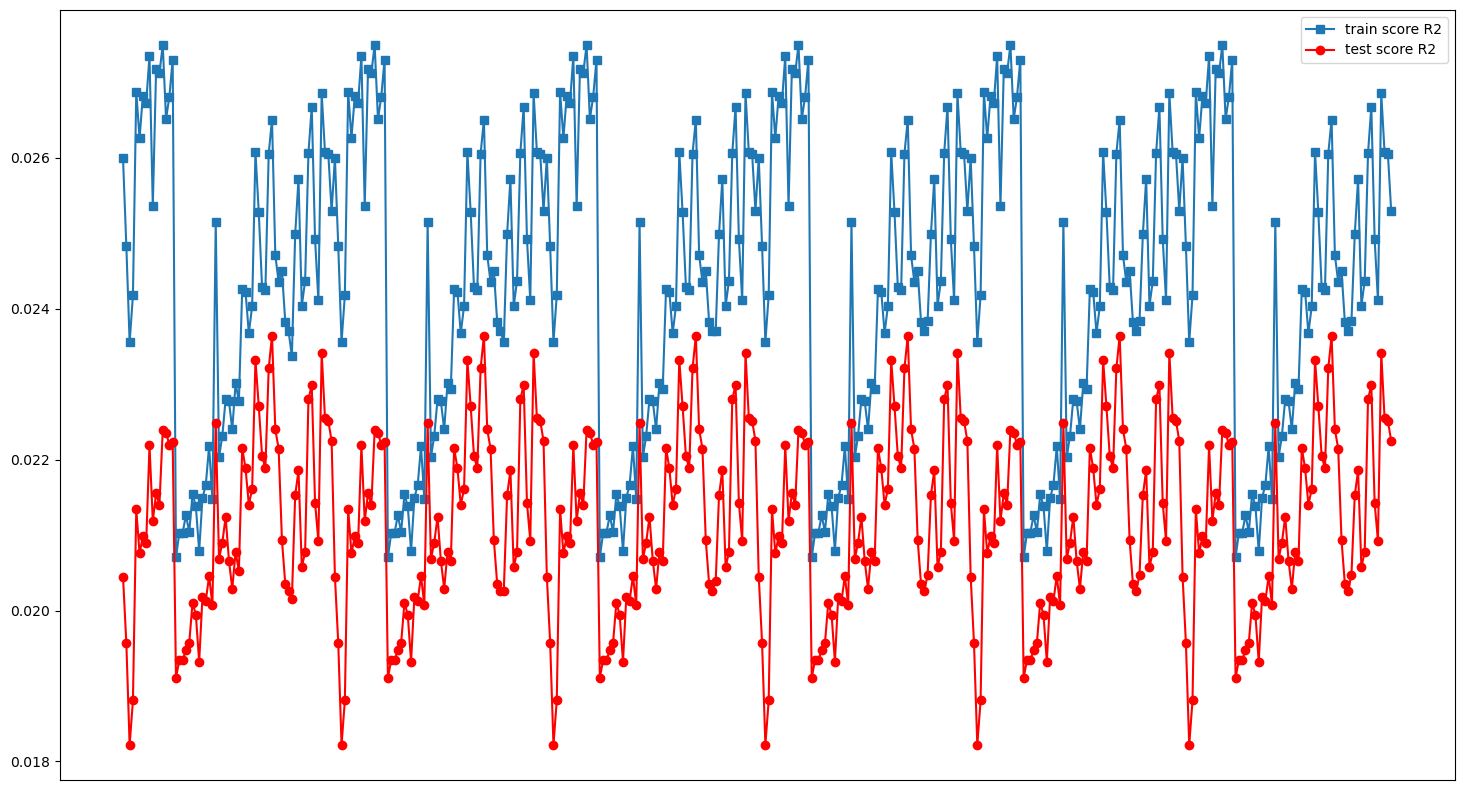

In [144]:
results = pd.DataFrame(grid_search.cv_results_)

# Expand the 'params' dict into separate columns
results["ID"] = (results.index + 1).astype(str)
results
X_axis_val = results["ID"]
Y_axis_val_train = results["mean_train_score"]
Y_axis_val_test = results["mean_test_score"]
plt.figure(figsize=(18, 10))
plt.plot(X_axis_val,Y_axis_val_train,label="train score R2",marker="s")
plt.plot(X_axis_val,Y_axis_val_test,label="test score R2",marker="o",color="Red")
plt.xticks([])
plt.legend()
best_score = np.argmax(Y_axis_val_test)
results.iloc[best_score]


30    {'epochs': 400, 'hidden_layers': [100, 50, 20]...
Name: params, dtype: object

In [ ]:
"""
Use kfold.
Compute MSE for train and validation.
Use few folds due to computation time/cost.


"""